
# 04 — Machine Learning Methods

**Project:** What Makes a Song Popular? A Data Analysis of Spotify Tracks

This notebook applies machine learning methods to the Spotify dataset and improves the original workflow using:

- Feature scaling before training
- Hyperparameter tuning with GridSearchCV
- Stratified K-Fold Cross Validation
- Detailed model comparison and interpretation
- Classification and regression tasks
- Clear markdown explanations for readability



## 0. Imports and Helper Functions

In this section, we import the required libraries for:

- Data manipulation
- Visualization
- Machine learning pipelines
- Hyperparameter tuning
- Cross-validation
- Model evaluation


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC



## 1. Load the Dataset

The project uses two Spotify datasets:

- High popularity songs
- Low popularity songs

The datasets are merged into a single dataframe and labeled for classification.


In [3]:

high = pd.read_csv("high_popularity_spotify_data.csv")
low = pd.read_csv("low_popularity_spotify_data.csv")

high["popularity_group"] = 1
low["popularity_group"] = 0

df = pd.concat([high, low], ignore_index=True)

print(df.shape)
df.head()


(4831, 30)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popularity_group
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1



## 2. Feature Selection and Cleaning

We keep the most relevant Spotify audio features and remove unnecessary identifiers.

The selected features represent:

- Rhythm and energy
- Loudness and tempo
- Emotional tone
- Acoustic properties


In [5]:

numeric_features = [
    "danceability",
    "energy",
    "loudness",
    "tempo",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness"
]

categorical_features = []

df = df.dropna(subset=["popularity_group"])

X = df[numeric_features + categorical_features].copy()
y = df["popularity_group"].astype(int)

print(X.shape)


(4831, 8)



## 3. Train-Test Split

The dataset is divided into training and testing subsets.

We use stratified splitting to preserve the class distribution.


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (3864, 8)
Testing shape: (967, 8)



## 4. Preprocessing Pipeline

Machine learning models perform better when features are scaled properly.

This preprocessing pipeline:

- Fills missing values using median imputation
- Applies StandardScaler to numeric features

Scaling is especially important for:

- Logistic Regression
- Support Vector Machines
- Distance-based models


In [7]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)



## 5. Classification Models and Hyperparameter Tuning

Instead of training models with default parameters, we use GridSearchCV with Stratified K-Fold Cross Validation.

This improves model reliability and helps identify better-performing parameter combinations.


In [9]:

classification_models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=5000),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "classifier__max_depth": [3, 5, 10, None],
            "classifier__min_samples_split": [2, 5, 10]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [5, 10, None]
        }
    },

    "SVM": {
        "model": SVC(probability=True),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"]
        }
    }
}

classification_results = []
trained_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, config in classification_models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "Precision": precision,
        "Recall": recall,
        "Best Params": grid.best_params_
    })

    trained_models[name] = best_model

classification_results_df = pd.DataFrame(classification_results)
classification_results_df = classification_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

classification_results_df


,Model,Accuracy,F1 Score,Precision,Recall,Best Params
2,Random Forest,0.705274,0.507772,0.607438,0.436202,"{'classifier__max_depth': None, 'classifier__n..."
1,Decision Tree,0.641158,0.503577,0.486188,0.522255,"{'classifier__max_depth': None, 'classifier__m..."
3,SVM,0.668046,0.456853,0.531496,0.400593,"{'classifier__C': 10, 'classifier__kernel': 'r..."
0,Logistic Regression,0.654602,0.409894,0.506550,0.344214,{'classifier__C': 1}



## 6. Detailed Model Comparison

We compare models using multiple evaluation metrics instead of only accuracy.

### Why multiple metrics matter

- Accuracy can be misleading in imbalanced datasets
- F1-score balances precision and recall
- Precision measures false positive control
- Recall measures ability to detect positive samples

### Model Interpretation

- Logistic Regression performs well when relationships are mostly linear
- Decision Trees may overfit small patterns
- Random Forest usually generalizes better because it combines many trees
- SVM performs strongly when classes are separable after scaling


In [10]:

classification_results_df


,Model,Accuracy,F1 Score,Precision,Recall,Best Params
2,Random Forest,0.705274,0.507772,0.607438,0.436202,"{'classifier__max_depth': None, 'classifier__n..."
1,Decision Tree,0.641158,0.503577,0.486188,0.522255,"{'classifier__max_depth': None, 'classifier__m..."
3,SVM,0.668046,0.456853,0.531496,0.400593,"{'classifier__C': 10, 'classifier__kernel': 'r..."
0,Logistic Regression,0.654602,0.409894,0.506550,0.344214,{'classifier__C': 1}



## 7. Plot: Classification Metric Comparison

This visualization compares model performance across different metrics.


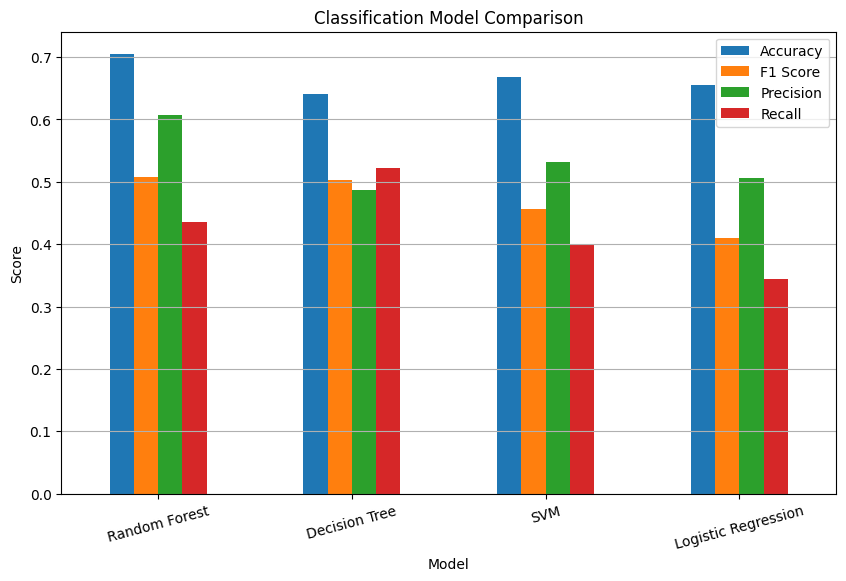

In [11]:

plot_df = classification_results_df.set_index("Model")[
    ["Accuracy", "F1 Score", "Precision", "Recall"]
]

plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()



## 8. Best Classification Model

The best classifier is selected according to F1-score.

We also inspect:

- Confusion matrix
- Classification report
- ROC curve


In [12]:

best_model_name = classification_results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))


Best Model: Random Forest
              precision    recall  f1-score   support

           0       0.74      0.85      0.79       630
           1       0.61      0.44      0.51       337

    accuracy                           0.71       967
   macro avg       0.67      0.64      0.65       967
weighted avg       0.69      0.71      0.69       967




## 9. Confusion Matrix

The confusion matrix shows:

- Correct classifications
- False positives
- False negatives

This helps identify which mistakes the model makes most frequently.


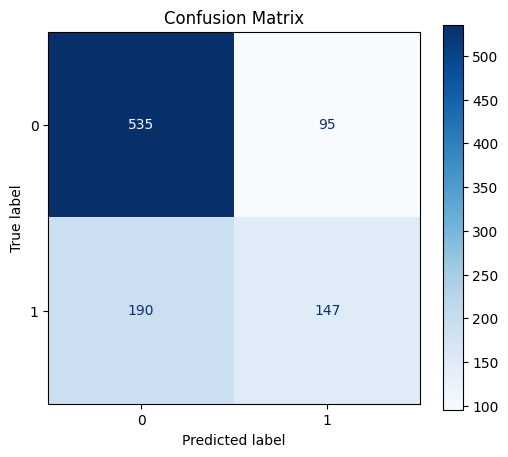

In [13]:

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()



## 10. ROC Curve

The ROC curve evaluates how well the classifier separates classes across different thresholds.


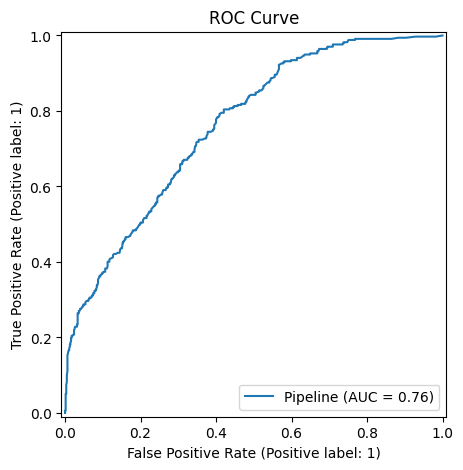

In [14]:

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=ax
)

plt.title("ROC Curve")
plt.show()



## 11. Regression Task: Predict Numeric Popularity

In addition to classification, we also predict the exact popularity score using regression models.


In [19]:

y_reg = df["track_popularity"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)



## 12. Regression Models and Cross Validation

We evaluate multiple regression models using:

- RMSE
- MAE
- R² score

Cross-validation improves reliability and reduces dependency on a single split.


In [20]:

regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}

regression_results = []

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in regression_models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train_reg,
        y_train_reg,
        cv=kfold,
        scoring=[
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error",
            "r2"
        ],
        n_jobs=-1
    )

    pipeline.fit(X_train_reg, y_train_reg)

    preds = pipeline.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2 = r2_score(y_test_reg, preds)

    regression_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values(
    by="RMSE"
)

regression_results_df


,Model,MAE,RMSE,R2
3,Random Forest Regressor,13.533160,17.297397,0.215468
1,Ridge Regression,15.618422,18.693247,0.083740
0,Linear Regression,15.618366,18.693295,0.083735
2,Decision Tree Regressor,17.321613,23.870453,-0.494069



## 13. Regression Model Interpretation

### Interpretation of Results

- Linear models perform well when relationships are simple and approximately linear
- Decision Trees can capture nonlinear behavior but may overfit
- Random Forest generally improves stability and prediction quality
- Ridge Regression helps reduce overfitting by regularization

### Important Observation

A lower RMSE and MAE indicate better prediction quality, while higher R² indicates stronger explanatory power.


In [22]:

regression_results_df


,Model,MAE,RMSE,R2
3,Random Forest Regressor,13.533160,17.297397,0.215468
1,Ridge Regression,15.618422,18.693247,0.083740
0,Linear Regression,15.618366,18.693295,0.083735
2,Decision Tree Regressor,17.321613,23.870453,-0.494069



## 14. Regression Performance Visualization

This plot compares RMSE values across regression models.


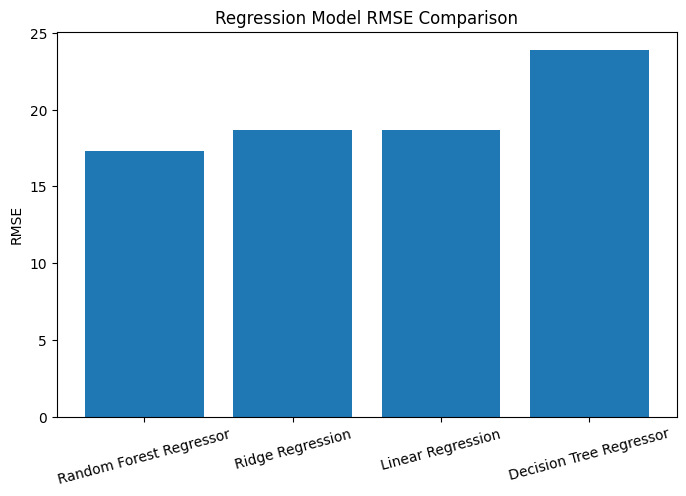

In [23]:

plt.figure(figsize=(8, 5))

plt.bar(
    regression_results_df["Model"],
    regression_results_df["RMSE"]
)

plt.title("Regression Model RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=15)

plt.show()



## 15. Final Discussion and Conclusions

### Main Improvements Compared to the Original Notebook

- Added feature scaling
- Added hyperparameter tuning
- Used K-Fold Cross Validation
- Compared multiple evaluation metrics
- Added detailed interpretation for each model

### Final Insights

- Ensemble methods such as Random Forest usually perform best because they reduce overfitting
- Scaled models such as Logistic Regression and SVM improved after normalization
- Cross-validation produced more reliable evaluation results
- Different metrics reveal different strengths and weaknesses of the models
